- Labels
- Each training and test example is assigned to one of the following labels:
- 
- 0 T-shirt/top
- 1 Trouser
- 2 Pullover
- 3 Dress
- 4 Coat
- 5 Sandal
- 6 Shirt
- 7 Sneaker
- 8 Bag
- 9 Ankle boot

[ fashoin 분류 ]
- 다중분류
- 지도학습 - 분류
- 이진분류

In [98]:
## 모듈로딩
import pandas as pd  # 데이터 모듈
import numpy as np

import torch         
# tensor 및 기본 함수 모듈   
import torch.nn as nn
# 인공신경망 관련 모듈
import torch.nn.functional as F
# 인공신경망 관련 함수
import torch.optim as optim
# 최적화 모듈

from sklearn.model_selection import train_test_split
# 학습용 데이터셋 관련 함수

from torchmetrics.classification import *
from torch.utils.data import Dataset, DataLoader

In [99]:
fasDF = pd.DataFrame(pd.read_csv('../_data/fashion/fashion-mnist_train.csv', engine='python'))

[2] 데이터 로딩 및 확인 <hr> 

In [100]:
fasDF.head()
fasDF.info()             

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB


In [101]:
# featureTs = torch.LongTensor(fasDF.iloc[:,1:].values)
# targetTs = torch.LongTensor(fasDF['label'].values)
featureTs = fasDF.iloc[:,1:]
targetTs = fasDF.iloc[:,0:1]


In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    featureTs, targetTs, train_size= 0.8, stratify=targetTs, random_state=42)

print(f"X_train => {X_train.ndim}D {X_train.shape} / X_test => {X_test.ndim}D, {X_test.shape}")
print(f"y_train => {y_train.ndim}D {y_train.shape}, / y_test => {y_test.ndim}D, {y_test.shape}")

X_train => 2D (48000, 784) / X_test => 2D, (12000, 784)
y_train => 2D (48000, 1), / y_test => 2D, (12000, 1)


In [103]:
## 데이터셋 클래스 생성

class FashionDataSet(Dataset):
    #피쳐와 타겟 분리 및 전처리 진행
    def __init__(self, featureDF, targetDF):
        super().__init__()
        self.feature = featureDF/255
        self.target = targetDF
        self.rows = featureDF.shape[0]
        self.cols = featureDF.shape[1]
        
    # 데이터셋의 샘플 수 반환 메서드
    def __len__(self):
        return self.rows
        
    # DataLoader 에서 batch_size만큼 호출하는 메서드
    # 인덱스에 해당하는 피쳐와 타겟 반환, 단 Tensor 형태
    def __getitem__(self, index):
        arrFeature = self.feature.iloc[index].values
        arrTarget = self.target.iloc[index].values    
        
        return torch.FloatTensor(arrFeature), torch.LongTensor(arrTarget)

In [104]:
dataset = FashionDataSet(fasDF.iloc[:,1:], fasDF.iloc[:,0:1])

In [105]:
dataset.feature.shape, dataset.target.shape

((60000, 784), (60000, 1))

In [106]:
## DataLoader 연동
loader = DataLoader(dataset, batch_size=1)
for feature, target in loader:
    print(feature, target)
    break


tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0157, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.2431, 0.2392, 0.0824, 0.1137, 0.0902,
         0.2000, 0.5333, 0.2392, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [107]:
trainDS = FashionDataSet(X_train, y_train)
testDS  = FashionDataSet(X_test, y_test)

[5] 모델 클래스 설계 및 구현 <hr>

In [128]:

class fas_Model(nn.Module):
    # 인스턴스 초기화 및 생성 메서드
    def __init__(self):
        super().__init__() #부모(nn.Module)의 init 생성
        print('__init__()')
        self.layers = nn.Sequential(
                        nn.Linear(784, 400),
                        nn.ReLU(),
                        nn.Linear(400, 200),
                        nn.ReLU(),
                        nn.Linear(200, 100),
                        nn.ReLU(),
                        nn.Linear(100, 50),
                        nn.ReLU(),
                        nn.Linear(50, 10),
                        
        )

    # 순전파 학습 메서드 
    def forward(self, data):
        return self.layers(data)
               

In [129]:
model = fas_Model()

__init__()


In [130]:
for feature, target  in testDS:
    pre_ = model(feature)
    print(pre_, target)
    print(pre_.max(), pre_.argmax())
    break

tensor([-0.0508,  0.1408, -0.1532, -0.0764, -0.0430, -0.0619,  0.0800, -0.1018,
         0.0701,  0.0848], grad_fn=<ViewBackward0>) tensor([5])
tensor(0.1408, grad_fn=<MaxBackward1>) tensor(1)


[5] 학습 준비<hr>

In [158]:
## [5-1] 학습 관련 설정들
EPOCHS = 10                                         # 학습용 DS를 처음부터 끝까지 1번 학습하는 것을 에포크
BATCH_SIZE = 1200                                      # DS를 학습량 만큼 나눈 사이즈
ITERATION = int(X_train.shape[0]/BATCH_SIZE)         # 학습용 DS이 분리된 수 => 1에포크에 W, b 업데이트 횟수
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"DEVICE : {DEVICE}, EPOCHS : {EPOCHS}, BATCH_SIZE : {BATCH_SIZE} ITERATION: {ITERATION}")
      

DEVICE : cpu, EPOCHS : 10, BATCH_SIZE : 1200 ITERATION: 40


In [159]:
# [5-2] 학습 관련 인스턴스들
TRAINDL   = DataLoader(trainDS, batch_size=BATCH_SIZE)  #학습용
TESTDL    = DataLoader(testDS,  batch_size=BATCH_SIZE)  #테스트용
LR      = 0.0001                                # Learning Rate
MODEL  = fas_Model()                           #학습 모델
OPTIMIZER = optim.Adam(MODEL.parameters(), lr=LR)      #최적화 즉, 경사하강법 알고리즘으로 W, b의 값 개신
LOSS_FN = nn.CrossEntropyLoss()


__init__()


In [160]:
##- 학습 함수 --------------------------------------------
##- 학습용 데이터셋으로 모델 검증
##- -----------------------------------------------------
def training():
    # 학습 모드 설정
    model.train()

    E_LOSS = 0
    E_ACC = 0
    #for i in range(ITERATION): 
    for feature, target in TRAINDL:
        # 배치 크기만큼 feature, target 로딩
        # print(feature.shape, target.shape)
                                                                            
        # 가중치 기울기 0 초기화
        OPTIMIZER.zero_grad()

        # 학습 진행
        pre_y = MODEL(feature)

        # 손실 계산
        loss = LOSS_FN(pre_y, target.reshape(-1).long())
        
        # 역전파 진행
        loss.backward()

        # 가중치/절편 업데이트
        OPTIMIZER.step()
        
        # 정확도 계산
        accuracy = MulticlassAccuracy(num_classes=10)
        acc = accuracy(pre_y, target.reshape(-1))
       
        E_ACC += acc.item()
        E_LOSS += loss.item()

    return E_LOSS/ITERATION, E_ACC/ITERATION

In [161]:
training()

(2.247189152240753, 0.2515388734638691)

In [162]:
# 학습함수
def evaluate():
    # 에포크 단위로 검증 => 검증 모드
    MODEL.eval()
    
    # W, b가 업데이트 해제
    with torch.no_grad():
        # 방법1) 테스트용 DL 적용
        T_LOSS, T_ACC, T_PRE, T_RECALL, CNT = 0, 0, 0, 0, 0
        for feature, target in TESTDL:            
            # 검증진행
            pre_y= MODEL(feature)
            
            # 손실 계산
            loss = LOSS_FN(pre_y, target.reshape(-1).long())
            
            # 정확도 계산
            accuracy = MulticlassAccuracy(num_classes=10)
            prescision = MulticlassPrecision(num_classes=10)
            recall = MulticlassRecall(num_classes=10)
            f1 = MulticlassF1Score(num_classes=10)
            
            
            T_PRE += prescision(pre_y, target.reshape(-1)).item()
            T_RECALL += recall(pre_y, target.reshape(-1)).item()
            T_ACC += accuracy(pre_y, target.reshape(-1)).item()
            T_LOSS += loss.item()
            CNT += 1
            return T_LOSS/CNT, T_ACC/CNT#, T_PRE/CNT, T_RECALL/CNT
    
        # 방법2) 전테 테스트데이터
        # DF/SR => Tensor화
        # 검증용 데이터셋 => 텐서화 ndarray ==> tensor변환
        x = torch.FloatTensor(X_test.values) 
        y = torch.FloatTensor(y_test.values)
        
        # 검증진행
        pre_y= MODEL(x)
        
        # 손실 계산
        loss = LOSS_FN(pre_y, y.reshape(-1).long())

        # 정확도 계산
        accuracy = MulticlassAccuracy(num_classes=3)
        acc = accuracy(pre_y, y.reshape(-1))
        
        return loss.item(), acc.item()

In [163]:
evaluate()

(2.1250662803649902, 0.4587021470069885)

In [164]:
# 방법 2: time 모듈 사용
import time

# 현재 시간을 초 단위로 출력
print(time.time())

# 포맷팅된 시간 출력
print(time.strftime("%H:%M:%S"))

1743406086.5431535
16:28:06


In [165]:
HIST ={'Train':[], 'Valid':[]}   
# 에포크 단위 학습/검증 진행 
for epoch in range(EPOCHS):
    a = time.time()
    trainLoss, trainAcc = training()
    validLoss, validAcc = evaluate()

    HIST['Train'].append((trainLoss, trainAcc))
    HIST['Valid'].append((validLoss, validAcc))

    print(f'\nEPOCH[{epoch}/{EPOCHS}]----------------')
    print(f'- TRAIN_LOSS {trainLoss:.5f}    ACC {trainAcc:.5f}')
    print(f'- VALID_LOSS {validLoss:.5f}    ACC {validAcc:.5f}')
    
    print(time.time()-a)
print(time.strftime("%H:%M:%S"))


EPOCH[0/10]----------------
- TRAIN_LOSS 1.82556    ACC 0.49418
- VALID_LOSS 1.46059    ACC 0.59198
4.214872121810913

EPOCH[1/10]----------------
- TRAIN_LOSS 1.13257    ACC 0.63949
- VALID_LOSS 0.91359    ACC 0.65840
4.511375665664673

EPOCH[2/10]----------------
- TRAIN_LOSS 0.81716    ACC 0.68742
- VALID_LOSS 0.77565    ACC 0.70423
4.574843168258667

EPOCH[3/10]----------------
- TRAIN_LOSS 0.72240    ACC 0.72946
- VALID_LOSS 0.70514    ACC 0.75383
4.728720188140869

EPOCH[4/10]----------------
- TRAIN_LOSS 0.66206    ACC 0.76746
- VALID_LOSS 0.65108    ACC 0.77890
4.794302463531494

EPOCH[5/10]----------------
- TRAIN_LOSS 0.61413    ACC 0.78927
- VALID_LOSS 0.60981    ACC 0.79312
4.685757875442505

EPOCH[6/10]----------------
- TRAIN_LOSS 0.57785    ACC 0.80324
- VALID_LOSS 0.57830    ACC 0.80346
4.8593573570251465

EPOCH[7/10]----------------
- TRAIN_LOSS 0.55038    ACC 0.81169
- VALID_LOSS 0.55392    ACC 0.81368
4.836499929428101

EPOCH[8/10]----------------
- TRAIN_LOSS 0.528

In [166]:
evaluate()

(0.5183418393135071, 0.8270540833473206)

In [176]:
# MODEL.eval()
xdata = range(10)
ydata1Loss = []
ydata1Acc = []
for loss, acc in HIST['Train']:
    ydata1Loss.append(loss)
    ydata1Acc.append(acc)
ydata2Loss = []
ydata2Acc = []
for loss, acc in HIST['Valid']:
    ydata2Loss.append(loss)
    ydata2Acc.append(acc)




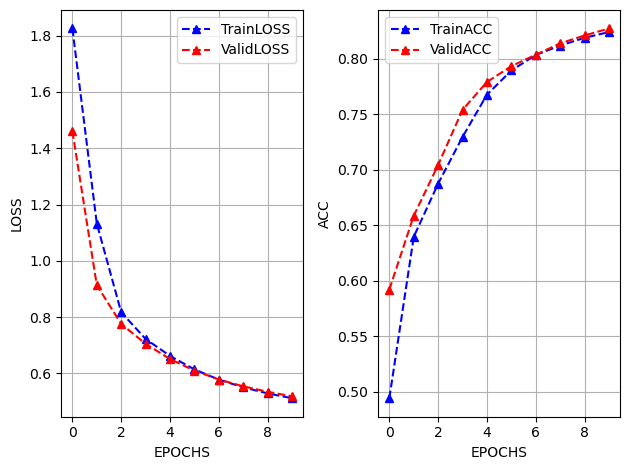

In [178]:
## 모델 성능 시각화 
import matplotlib.pyplot as plt

# plt.plot(HIST['Train'][0], 'b^--', label='TrainLOSS')
# plt.plot(HIST['Valid'][0], 'r^--', label='ValidLOSS')
# plt.plot(HIST['Train'][1], 'bo--', label='TrainACC')
# plt.plot(HIST['Valid'][1], 'ro--', label='ValidACC')

fig, ax = plt.subplots(1,2)
ax = ax.flatten()
ax[0].plot(ydata1Loss, 'b^--', label='TrainLOSS')
ax[1].plot(ydata1Acc, 'b^--', label='TrainACC')

ax[0].plot(ydata2Loss, 'r^--', label='ValidLOSS')
ax[1].plot(ydata2Acc, 'r^--', label='ValidACC')


ax[0].grid()
ax[1].grid()
ax[0].legend()
ax[1].legend()
ax[0].set_xlabel('EPOCHS')
ax[1].set_xlabel('EPOCHS')

ax[0].set_ylabel('LOSS')
ax[1].set_ylabel('ACC')
plt.tight_layout()
plt.show()